In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import pcse
from pcse.base import ParameterProvider
from pcse.input import YAMLCropDataProvider
from pcse.input import NASAPowerWeatherDataProvider
from pcse.models import Wofost81_PP
import yaml
latitude = 52.64
longitude = 6.32
input_dir = Path("/input")
agro_fp = input_dir / "9_Wofost81_PP_agro.yaml"
soil_fp = input_dir / "9_Wofost81_PP_soil.yaml"
site_fp = input_dir / "9_Wofost81_PP_site.yaml"
weather_fp = input_dir / "9_weather.csv"



ModuleNotFoundError: No module named 'matplotlib'

In [48]:
import datetime as dt
import requests
from pcse.input.nasapower import NASAPowerWeatherDataProvider
from pcse.exceptions import PCSEError

class NASAPowerWeatherDataProviderRangeNoTOA(NASAPowerWeatherDataProvider):

    def __init__(self, latitude, longitude, start_date, end_date, **kwargs):
        self._custom_start_date = start_date
        self._custom_end_date = end_date

        # Replace the variable list: remove TOA_SW_DWN
        self.power_variables = [
            "ALLSKY_SFC_SW_DWN", "T2M", "T2M_MIN", "T2M_MAX", "T2MDEW", "WS2M", "PRECTOTCORR"
        ]
        super().__init__(latitude, longitude, **kwargs)

  #  def _estimate_AngstAB(self, df_power):
   #     return self.angstA, self.angstB

    def _query_NASAPower_server(self, latitude, longitude):
        start_date = self._custom_start_date
        end_date = self._custom_end_date

        server = "https://power.larc.nasa.gov/api/temporal/daily/point"
        payload = {
            "request": "execute",
            "parameters": ",".join(self.power_variables),
            "latitude": float(latitude),
            "longitude": float(longitude),
            "start": start_date.strftime("%Y%m%d"),
            "end": end_date.strftime("%Y%m%d"),
            #"community": "AG",
            #"format": "JSON",
            # NOTE: omit "user" to match current docs/examples
        }

        req = requests.get(server, params=payload, timeout=60)
        if req.status_code != 200:
            # POWER returns useful details in the body for 422; show it
            raise PCSEError(f"HTTP {req.status_code} URL={req.url}\nResponse:\n{req.text[:1000]}")
        return req.json()

In [49]:
latitude = 52.64
longitude = 6.32

weather_data = NASAPowerWeatherDataProviderRangeNoTOA(
    latitude, longitude,
    start_date=dt.date(2018, 1, 1),
    end_date=dt.date(2025, 12, 30),
    force_update=True
)

In [50]:
df_weather = pd.DataFrame(weather_data.export())

In [51]:
print(type(soil_fp), soil_fp)
print(type(site_fp), site_fp)
print(type(agro_fp), agro_fp)

<class 'pathlib.PosixPath'> /Users/panyue/PycharmProjects/wofost_example_test/input/9_Wofost81_PP_soil.yaml
<class 'pathlib.PosixPath'> /Users/panyue/PycharmProjects/wofost_example_test/input/9_Wofost81_PP_site.yaml
<class 'pathlib.PosixPath'> /Users/panyue/PycharmProjects/wofost_example_test/input/9_Wofost81_PP_agro.yaml


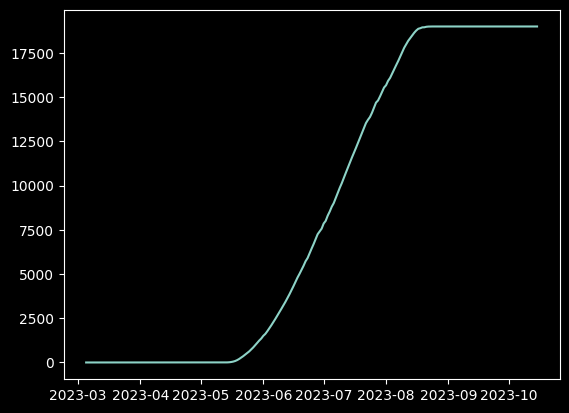

In [54]:
output_dir = cwd / "output"
fig_fp = output_dir / "output_sim_griddedweather.jpeg"

with open(agro_fp, "r") as f:
    agro_dict = yaml.safe_load(f)

with open(soil_fp, "r") as f:
    soil_dict = yaml.safe_load(f)

with open(site_fp, "r") as f:
    site_dict = yaml.safe_load(f)

crop_dict = YAMLCropDataProvider(Wofost81_PP)
parameters = ParameterProvider(sitedata=site_dict, soildata=soil_dict, cropdata=crop_dict)
wofost = Wofost81_PP(parameters, weather_data, agro_dict)

wofost.run_till_terminate()
output = wofost.get_output()
df_output = pd.DataFrame(output)

fig, ax = plt.subplots()
ax.plot(df_output["day"], df_output["WSO"])
fig.savefig(fig_fp)